### Testing space for uMux model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *

from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar


In [3]:

loaded_data = np.loadtxt('data/NIST_full_s21.txt', dtype=complex)

freqs_loaded = np.real(loaded_data[:, 0])
s21_loaded = loaded_data[:, 1]
s21_db_loaded = np.abs(s21_loaded) 
s21_phase = np.angle(s21_loaded)
s21_logMag = 20*np.log10(s21_db_loaded)
s21_logMag = s21_logMag-np.max(s21_logMag)



In [4]:
data = np.load('data/flux_response_params.npz')
print(data)
ibias = data['ibias']
I0fits = data['I0fits']
Minfits = data['Minfits']
Mcfits = data['Mcfits']
fbfits = data['fbfits']
lambfits = data['lambfits']


NpzFile 'data/flux_response_params.npz' with keys: ibias, I0fits, Minfits, Mcfits, fbfits...


In [5]:
meas_flux = np.load('data/measured_flux_response.npz')
ibias = meas_flux['ibias']
dfs = meas_flux['freqs']

0.005052777279566963 86830.39513443755
0.005046094950979472 81939.13330157114
0.005039643173909713 124707.19052472038
0.005033288667237745 129774.55974164061
0.005027206701957587 78273.59065690743
0.00502096499969659 131617.49003100547
0.005014572401255705 139256.72912152557
0.005008222449665796 130301.86969344183
0.0050022066917329985 99737.02110146605
0.00499532167600222 90739.56691385526
0.004989229953206562 70897.21466636371
0.004982322495270194 79698.82926353476
0.004975878680991662 87313.93054860207
0.004970053669453078 174681.55385441205
0.004962593371183802 88725.93906254249
0.004956523418137672 171627.84863874753
0.004950127310721884 1000000000000.0
0.0049427769369283754 82917.32925844779
0.0049366753672677914 67678.88797738268
0.004930174775030939 89162.0325794188
0.0049243460057420115 91558.70326130158
0.00491855491902788 93483.8791953501
0.004912199122904219 82138.8944879146
0.004905902388782301 95947.01806122303
0.00489942227559951 107860.32328160045
0.0048929849371803415 

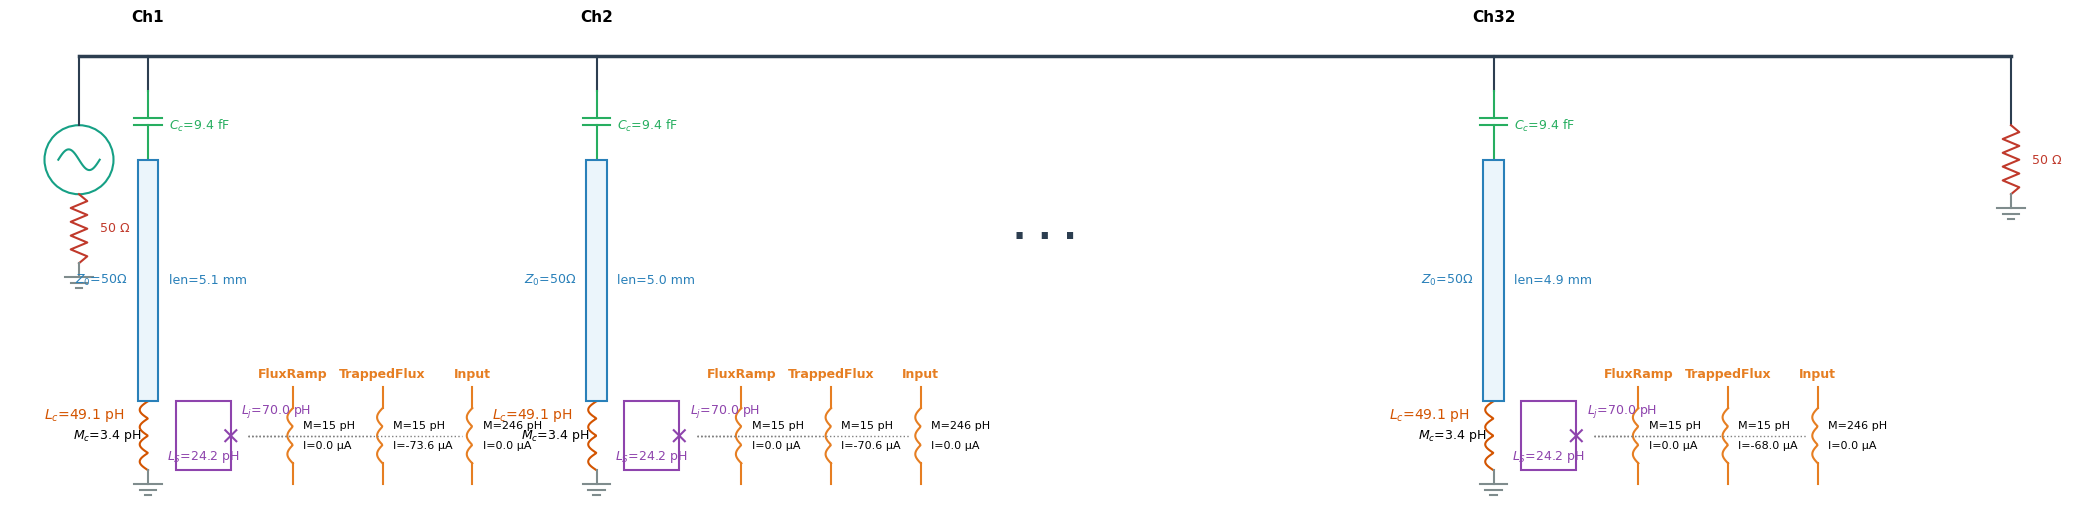

In [6]:

circle_params = np.loadtxt('data/NIST_full_params.txt', dtype=float)

VNA = VNA_Simulator(z0=50)

squids = []
num_channels = 32

for i in range(num_channels):
    squid_ch = SQUID(L_j=70e-12, L_s=24.2e-12, lamb=None, phi_ext=0.0) 
    squid_ch.add_flux_line("FluxRamp", M=15e-12, initial_current=0.0)
    squid_ch.add_flux_line("TrappedFlux", M=15e-12, initial_current=0.0)
    squid_ch.add_flux_line("Input", M=246e-12)   
    
    ind_ch = Inductor(49.1e-12)
    tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)
    squids.append(squid_ch)


    circ_fit = np.copy(circle_params[i]) 
    circ_fit[2] = circ_fit[2] + fbfits[i] 

    
    length, Cc_val, Qi_val = extract_physical_params(circ_fit, tuned_L_ch, Cc_in=9.4e-15)

    print(length, Qi_val )
    squid_ch.set_current("TrappedFlux", I0fits[i])

    cap_ch = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val)

    channel = Channel(name=f"Ch{i+1}") 
    channel.add(cap_ch)
    channel.add(phys_res)

    
    
    VNA.add(channel, 'shunt')

VNA.draw_schematic(use_color=True, max_draw=1)

(2000, 2, 2)


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


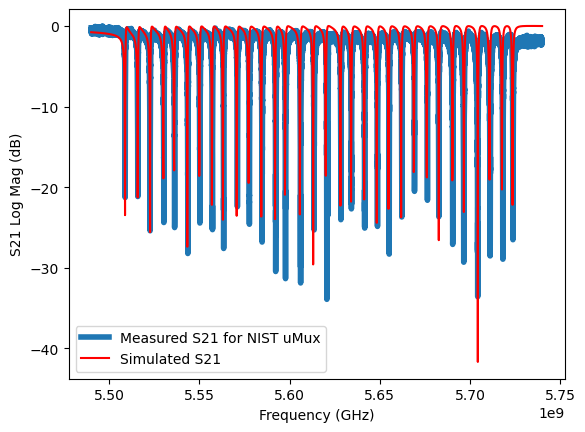

In [7]:
freqs = np.linspace(np.min(freqs_loaded),np.max(freqs_loaded),2000)
S = VNA.get_s_matrix(freqs)


plt.plot(freqs_loaded, s21_logMag,markersize = 0.5, label = "Measured S21 for NIST uMux", linewidth = 4)
plt.plot(freqs, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.legend()
# plt.xlim([5.6e9,5.61e9])
plt.show()

In [8]:

    


I_array = np.linspace(0,300e-6,300)

#Splines interpolation was suggested to make this faster
from scipy.interpolate import CubicSpline

coarse_steps = 50
I_array_coarse = np.linspace(0, 300e-6, coarse_steps)
I_array_dense = np.linspace(0, 300e-6, 300) 

flux_array = []
for squid in squids:
    squid.flux_lines["FluxRamp"].I = I_array_dense
    flux_array.append(I_array_dense * squid.flux_lines["FluxRamp"].M)
    
channels = [comp for comp, mode in VNA.chain if isinstance(comp, Channel)]
num_channels = len(channels)

frs_coarse = np.zeros((coarse_steps, num_channels))

for squid in squids:
    squid.flux_lines["FluxRamp"].I = 0.0

S_baseline = VNA.get_s_matrix(freqs_loaded)
baseline_peaks_idx = find_all_peaks(freqs_loaded, S_baseline[1, 0])
baseline_frs = freqs_loaded[baseline_peaks_idx]

if len(baseline_frs) != num_channels:
    print(f"Warning: Found {len(baseline_frs)} peaks but have {num_channels} channels.")

for i, current in enumerate(I_array_coarse):
    for squid in squids:
        squid.flux_lines["FluxRamp"].I = current
        
    for c_idx, channel in enumerate(channels):
        guess = baseline_frs[c_idx] if i == 0 else frs_coarse[i-1, c_idx]
        frs_coarse[i, c_idx] = channel.get_resonance(f_guess=guess)

frs = np.zeros((len(I_array_dense), num_channels))

for c_idx in range(num_channels):
    spline = CubicSpline(I_array_coarse, frs_coarse[:, c_idx])
    frs[:, c_idx] = spline(I_array_dense)

print("Tracking complete. Shape of frs:", np.shape(frs))

(25616, 2, 2)
Tracking complete. Shape of frs: (300, 32)


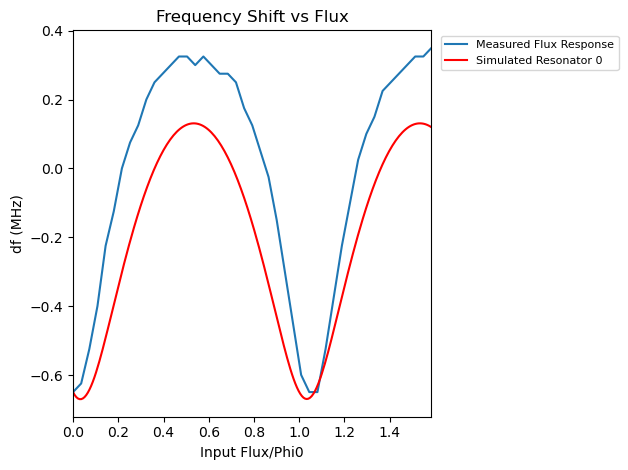

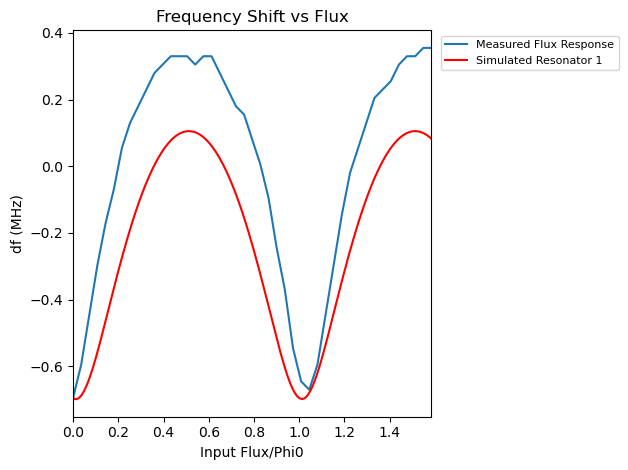

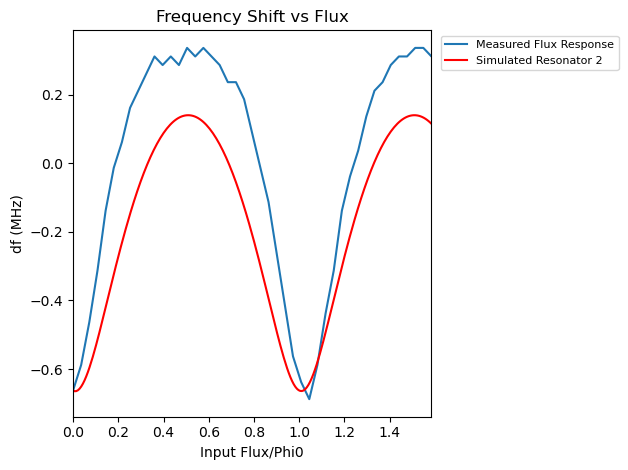

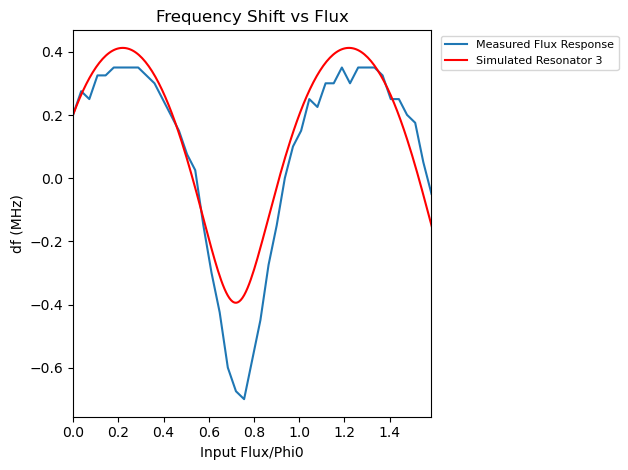

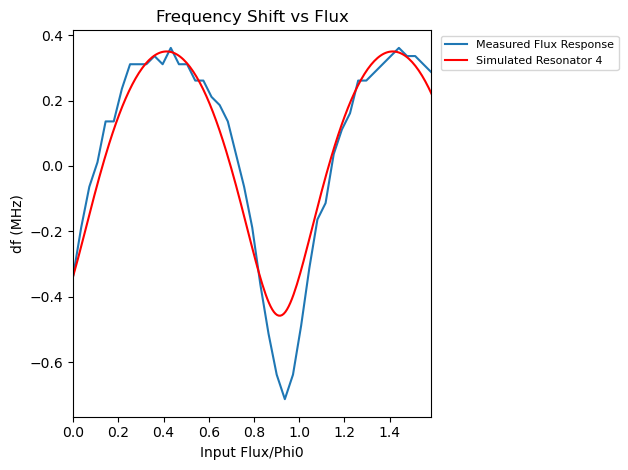

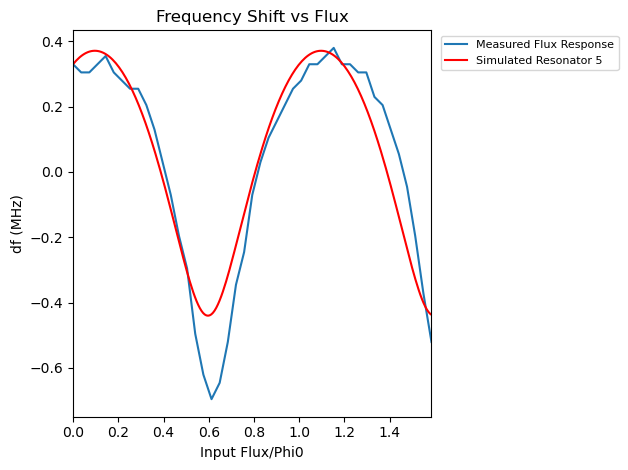

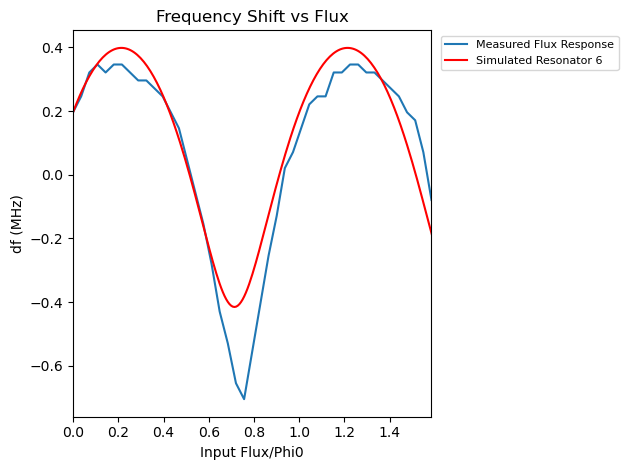

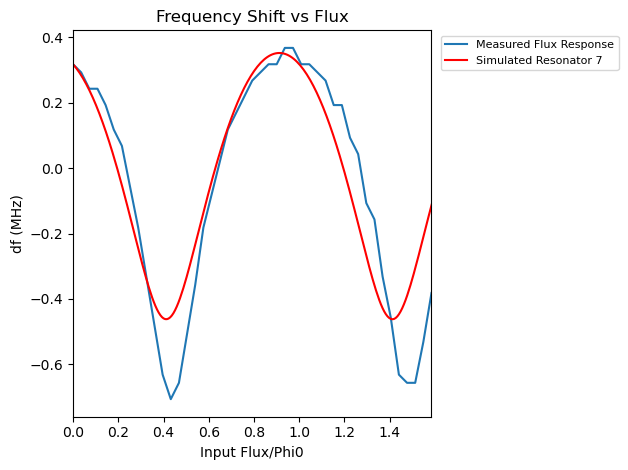

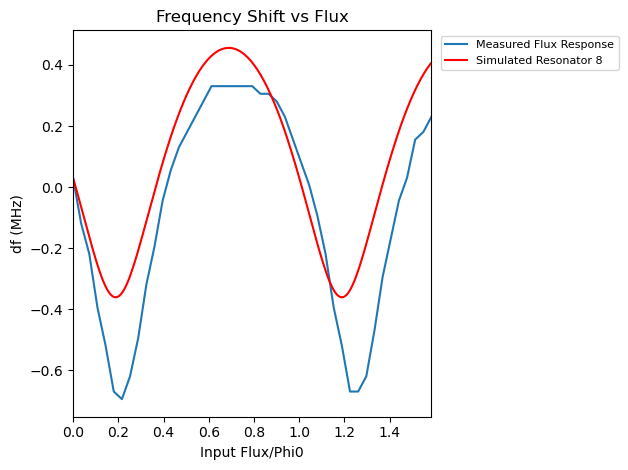

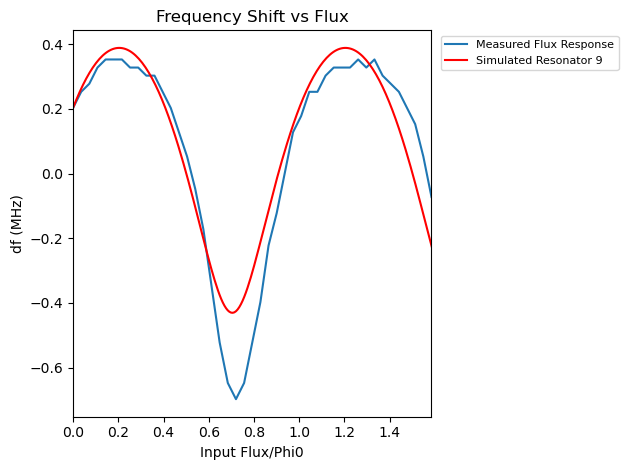

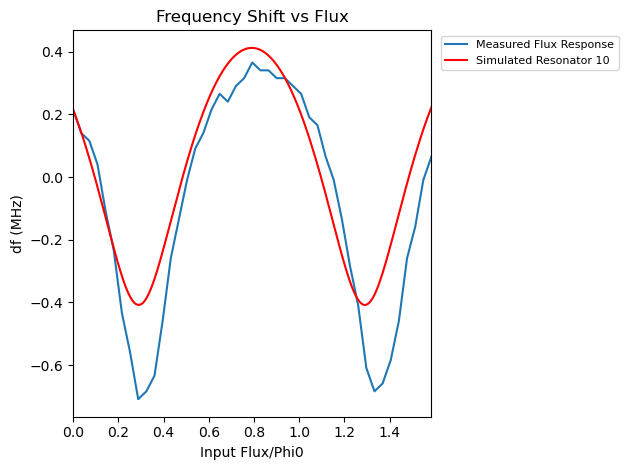

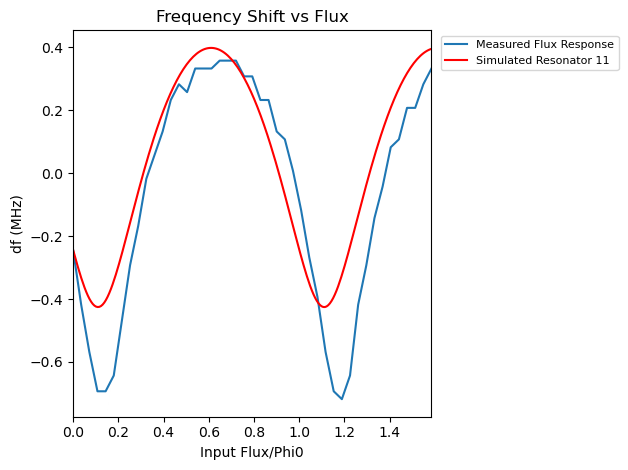

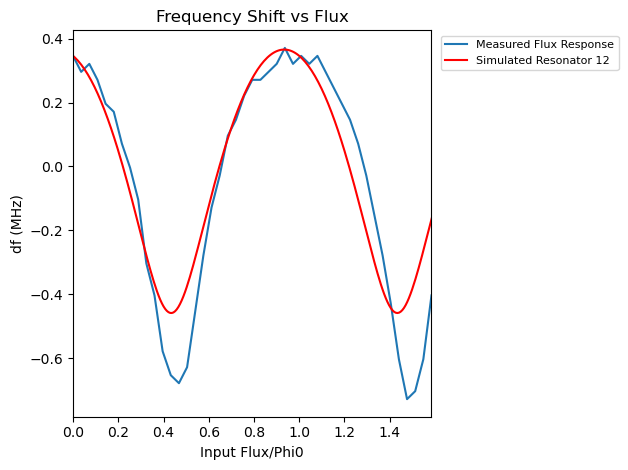

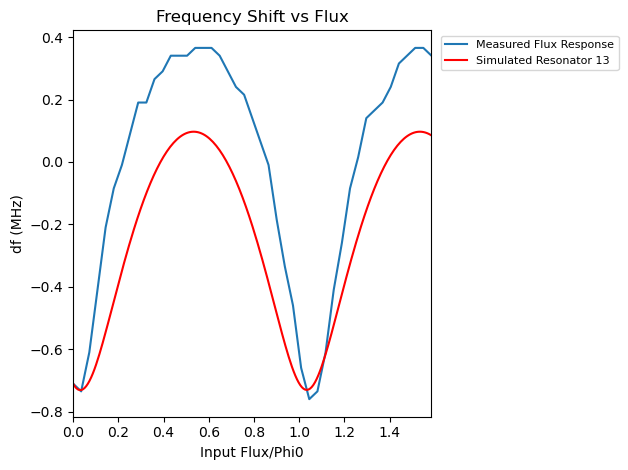

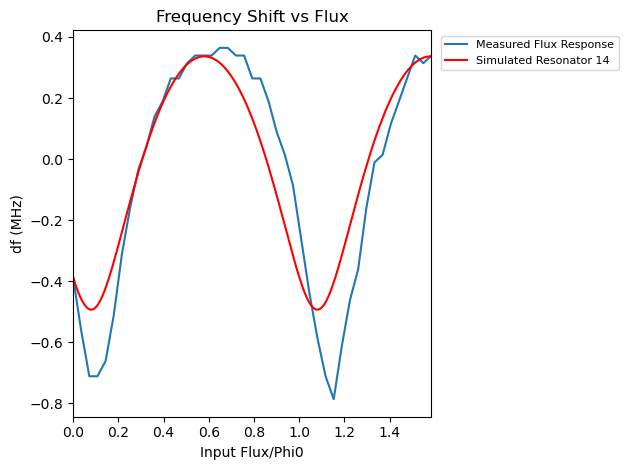

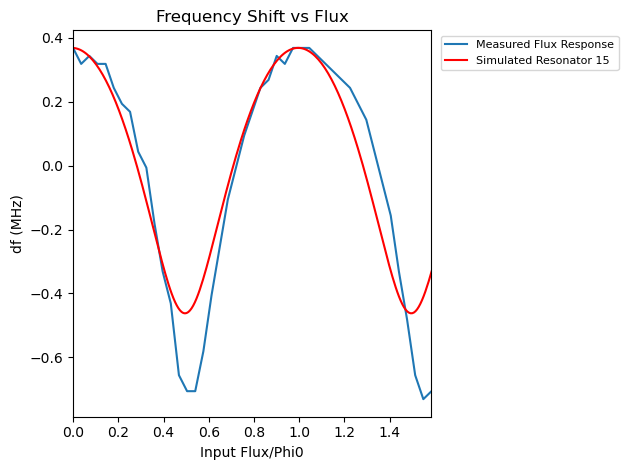

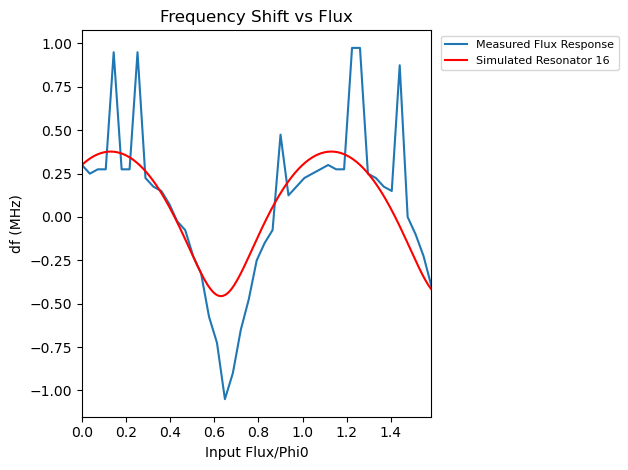

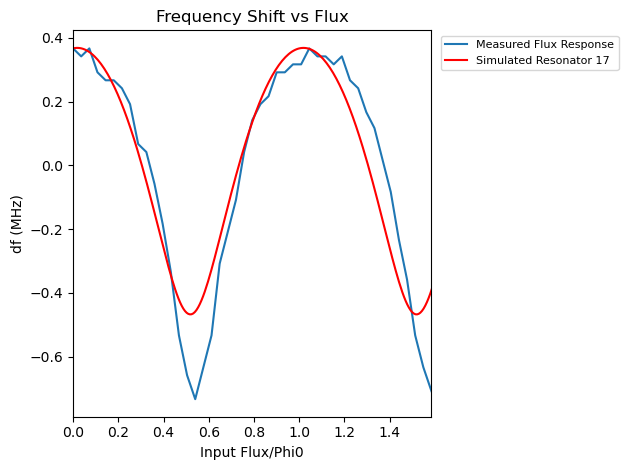

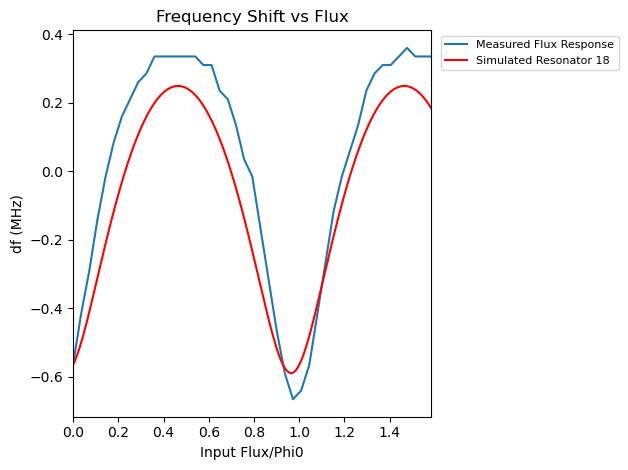

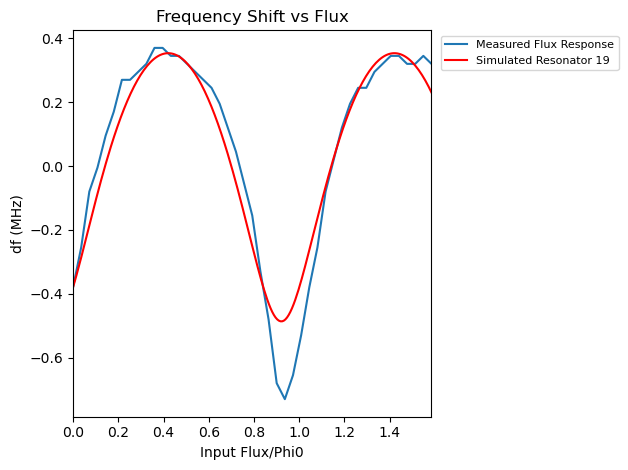

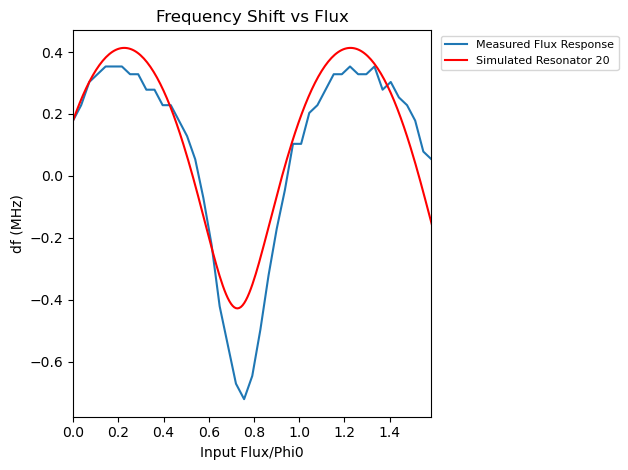

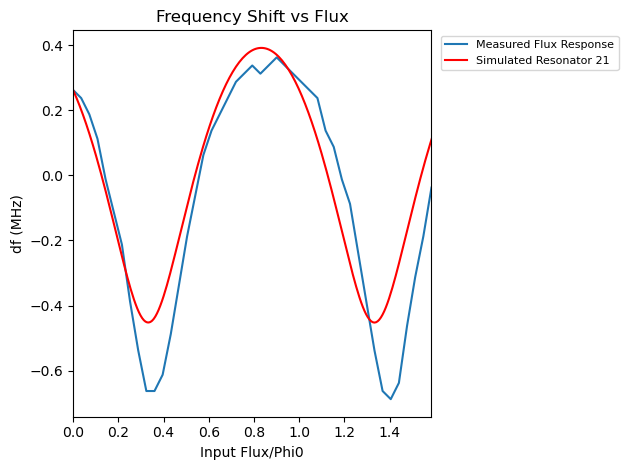

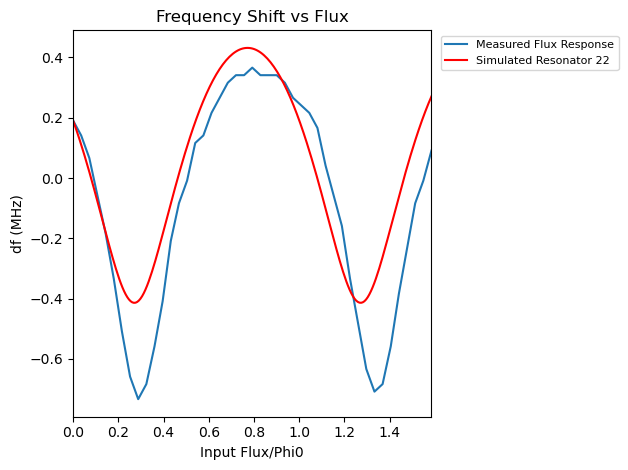

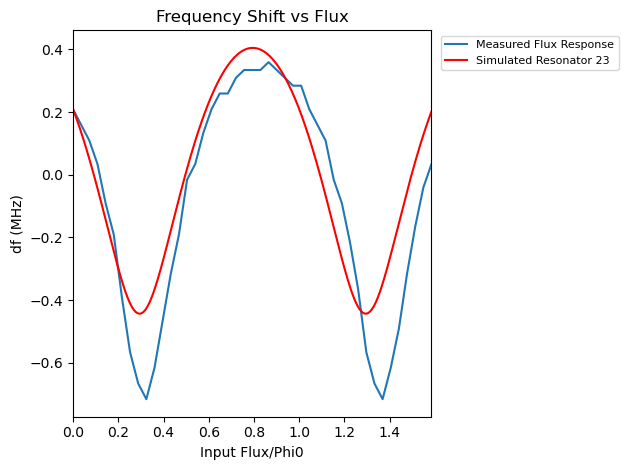

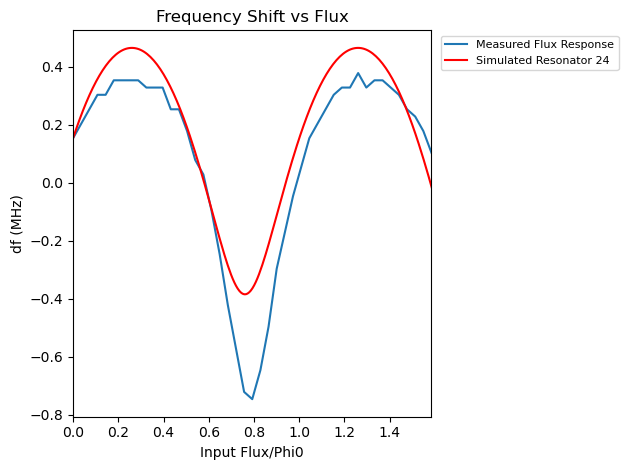

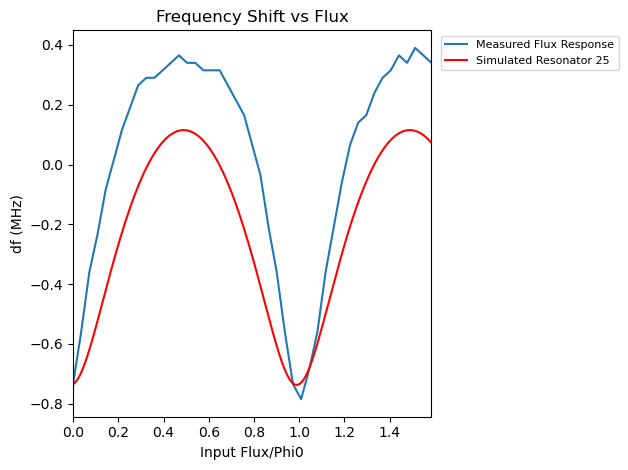

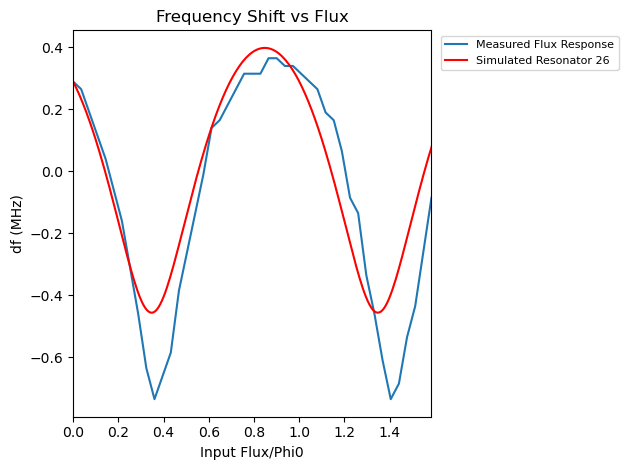

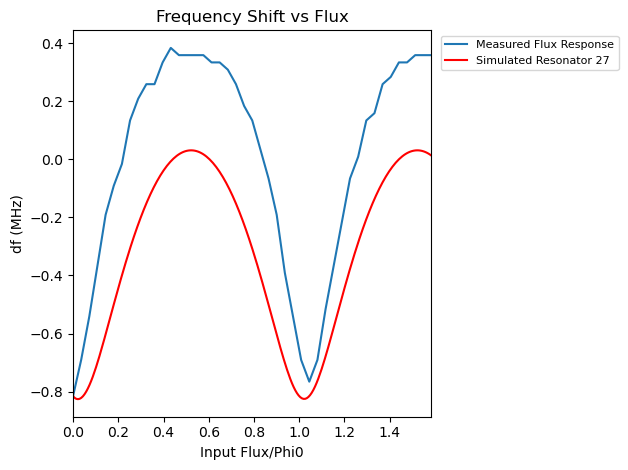

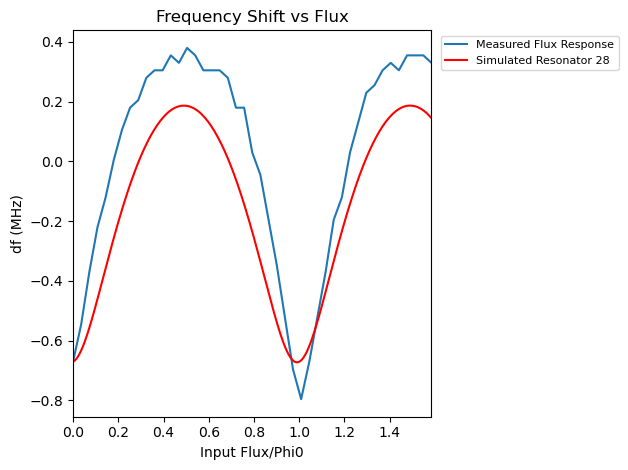

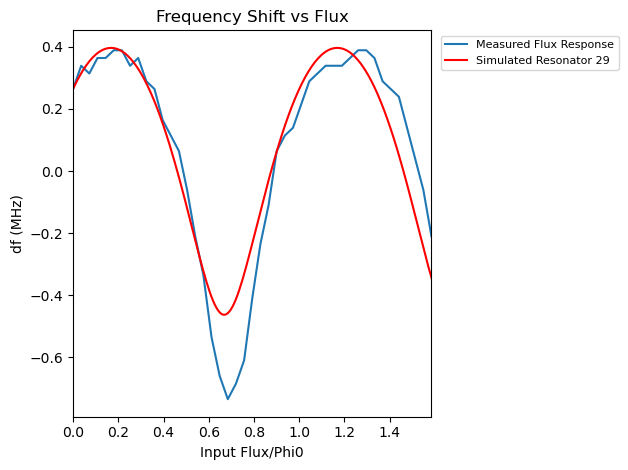

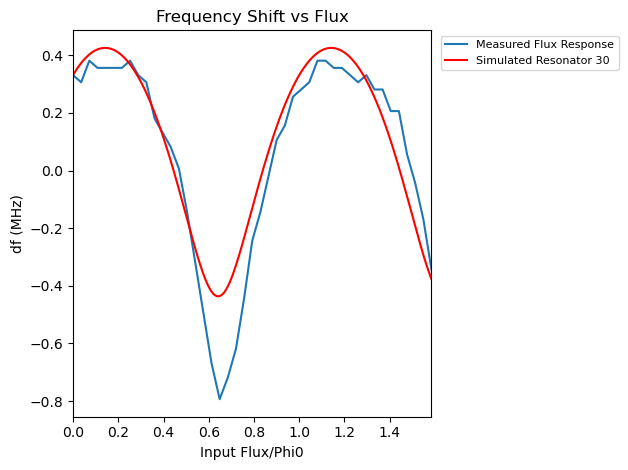

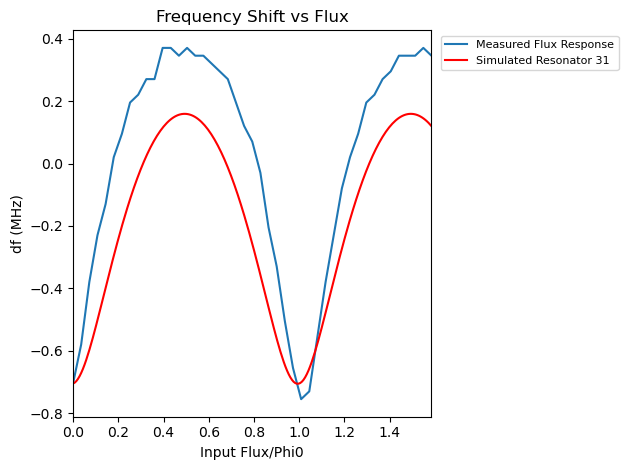

In [11]:


dfreqs = frs - frs[0, :]
fluxes = []

for squid in squids:
    fluxes.append(ibias*squid.flux_lines["FluxRamp"].M)

for p in range(num_channels):
    
    plt.plot(fluxes[p]/Phi0, 1e-6*(dfs[p]-fbfits[p]),label = "Measured Flux Response")
    plt.plot(flux_array[p]/Phi0, 1e-6*(dfreqs[:, p]-fbfits[p]), label=f"Simulated Resonator {p}", color = 'r')
    
    plt.xlim([np.min(fluxes[p])/Phi0,np.max(fluxes[p])/Phi0])
    plt.xlabel("Input Flux/Phi0")
    plt.ylabel("df (MHz)")
    plt.title("Frequency Shift vs Flux")

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=0.5, fontsize=8, ncol=1)
    plt.tight_layout()
    plt.show()

[0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857, 0.3457142857142857]


Text(0.5, 0, 'Lambda')

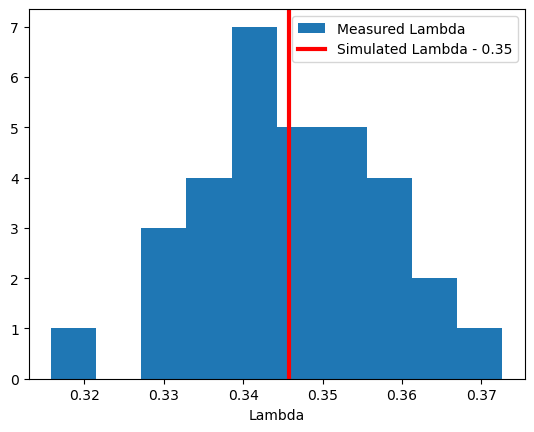

In [10]:
plt.hist(lambfits, label = "Measured Lambda")

lambs = []
for squid in squids:
    lambs.append(squid.lamb)
    
print(lambs)
    
plt.axvline(lambs[0], 0,7, color = 'r', linewidth = 3,label = "Simulated Lambda - "+str(np.round(lambs[0],2)))
plt.legend()
plt.xlabel("Lambda")


